In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from tueplots import figsizes

from tueplots import cycler
from tueplots.constants import markers
from tueplots.constants.color import palettes


# Increase the resolution of all the plots below
plt.rcParams.update({"figure.dpi": 150})

In [2]:
def exponentiated_quadratic(xa, xb,amplitude=1.0, length_scale=1.0):
    sq_dists = (np.sum(xa**2, 1)[:, None]
                - 2 * xa @ xb.T
                + np.sum(xb**2, 1)[None, :])
    sq_dists = np.maximum(sq_dists, 0.0)
    return  amplitude**2 *np.exp((-1/2)*(sq_dists)/ length_scale**2)

In [32]:
nb_of_samples = 100 
number_of_functions = 5 
X = np.expand_dims(np.linspace(-4, 4, nb_of_samples), 1)
Σ = exponentiated_quadratic(X, X, length_scale=1, amplitude=0.3)  # Kernel of data points

ys = np.random.multivariate_normal(
    mean=np.zeros(nb_of_samples), cov=Σ, size=number_of_functions
)

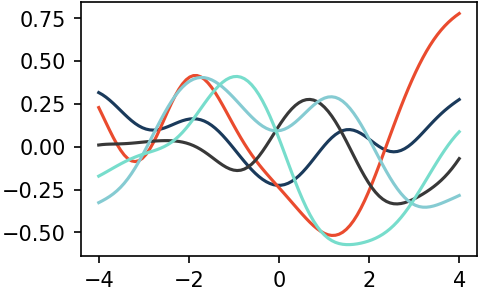

In [33]:
fig, ax = plt.subplots()
ax.plot(X[:, 0], ys.T) 
params = figsizes.icml2022_half()
plt.rcParams.update(params)

plt.rcParams.update(cycler.cycler(color=palettes.tue_ai))
plt.show()

In [8]:
class Kernel:
    def __init__(self,covar_func, signal_var, lengthscale):
        self.signal_var = signal_var
        self.lengthscale = lengthscale
        self.covar = covar_func

In [38]:
def GP(X1, y1, X2, kernel: Kernel, observ_noise=0):
    """
    Condition a noise-free GP prior to illustrate posterior regression.

    Calculates the posterior mean and covariance matrix for y2
    based on the corresponding input X2, the observations (y1, X1),
    and the prior kernel function.
    """
    kernel_func = kernel.covar
    # Kernel of the observations
    Σ11 = kernel_func(X1, X1, amplitude=kernel.signal_var, length_scale=kernel.lengthscale)+ ((observ_noise**2) * np.eye(X1.shape[0]))
    Σ11 = 0.5 * (Σ11 + Σ11.T) + 1e-8 * np.eye(len(X1))
    # Kernel of observations vs to-predict
    Σ12 = kernel_func(X1, X2, amplitude=kernel.signal_var, length_scale=kernel.lengthscale)
    # Solve
    solved = scipy.linalg.solve(Σ11, Σ12, assume_a="pos").T
    # Compute posterior mean
    μ2 = solved @ y1
    # Compute the posterior covariance
    Σ22 = kernel_func(X2, X2, kernel.signal_var, kernel.lengthscale)
    Σ2 = Σ22 - (solved @ Σ12)
    return μ2, Σ2  # mean, covariance

In [55]:
def f_sin(x):
    """Provide the toy target function used for regression examples."""
    return np.sin(x).flatten()


n1 = 5  # Number of points to condition on (training points)
n2 = 100  # Number of points in posterior (test points)
ny = 5  # Number of functions that will be sampled from the posterior
domain = (-4, 4)

X1 = np.random.uniform(domain[0] + 1, domain[1] - 1, size=(n1, 1))
y1 = f_sin(X1)
X2 = np.linspace(domain[0], domain[1], n2).reshape(-1, 1)
kernel = Kernel(covar_func=exponentiated_quadratic, lengthscale=1,signal_var=1)
mu2, Σ2 = GP(X1, y1, X2, kernel, observ_noise=0.1)
o2 = np.sqrt(np.diag(Σ2))

y2 = np.random.multivariate_normal(mean=mu2, cov=Σ2, size=ny)

In [56]:
def confidence_region(mu2,o2):
    lower = mu2 - 1.96 * o2
    upper = mu2 + 1.96 * o2
    return lower,upper

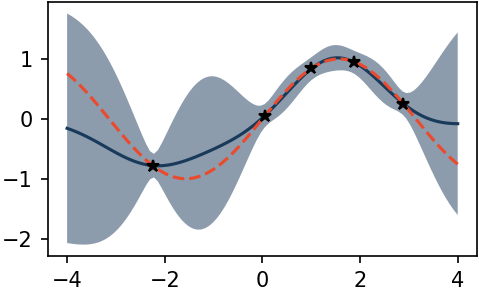

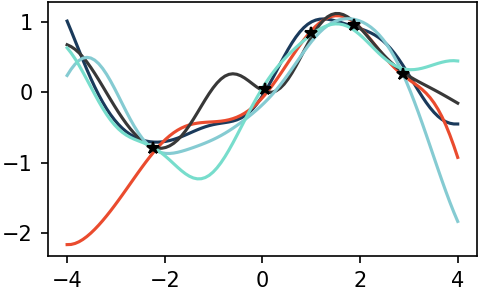

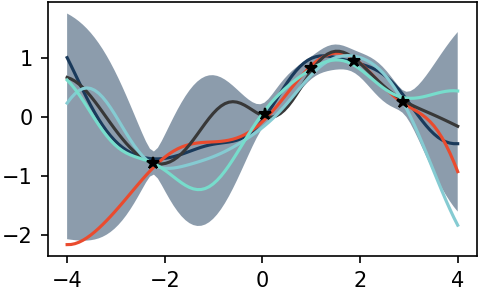

In [57]:
upper, lower = confidence_region(mu2, o2)
x_sin = np.linspace(domain[0], domain[1], 201)
params = figsizes.icml2022_half(ncols=1, nrows=1)
plt.rcParams.update(params)

plt.rcParams.update(cycler.cycler(color=palettes.tue_ai))
fig, ax = plt.subplots(1,1)
ax.plot(X2[:, 0],mu2.T)
ax.plot(x_sin,f_sin(x_sin),linestyle='--')
ax.fill_between(X2[:, 0], lower, upper, alpha=0.5)
ax.plot(X1[:, 0],y1.T, 'k*')


params = figsizes.icml2022_half(ncols=1, nrows=1)
plt.rcParams.update(params)

plt.rcParams.update(cycler.cycler(color=palettes.tue_ai))
fig, ax = plt.subplots(1,1)

ax.plot(X2[:, 0], y2.T) 
ax.plot(X1[:, 0],y1.T, 'k*')
#ax[0].legend(['Mean',"Sin(x)",'Confidence', 'Observed Data'])
plt.show()

upper, lower = confidence_region(mu2, o2)
x_sin = np.linspace(domain[0], domain[1], 201)
params = figsizes.icml2022_half(ncols=1, nrows=1)
plt.rcParams.update(params)

plt.rcParams.update(cycler.cycler(color=palettes.tue_ai))
fig, ax = plt.subplots(1,1)
ax.fill_between(X2[:, 0], lower, upper, alpha=0.5)
#ax[0].plot(x_sin,f_sin(x_sin),linestyle='--')
ax.plot(X2[:, 0], y2.T) 
#ax[0].legend(['Mean',"Sin(x)",'Confidence', 'Observed Data'])
ax.plot(X1[:, 0],y1.T, 'k*')
plt.show()

In [45]:
n1 = 5  # Number of points to condition on (training points)
n2 = 100  # Number of points in posterior (test points)
ny = 5  # Number of functions that will be sampled from the posterior
domain = (-4, 4)
obs_noise = 0.1

X1 = np.random.uniform(domain[0] + 1, domain[1] - 1, size=(n1, 1))
y1 = f_sin(X1)
y1 = y1 + (obs_noise * np.random.randn(n1))

X2 = np.linspace(domain[0], domain[1], n2).reshape(-1, 1)
kernel = Kernel(covar_func=exponentiated_quadratic, lengthscale=1,signal_var=1)
mu2, Σ2 = GP(X1, y1, X2, kernel, obs_noise)
o2 = np.sqrt(np.diag(Σ2))

y2 = np.random.multivariate_normal(mean=mu2, cov=Σ2, size=ny)

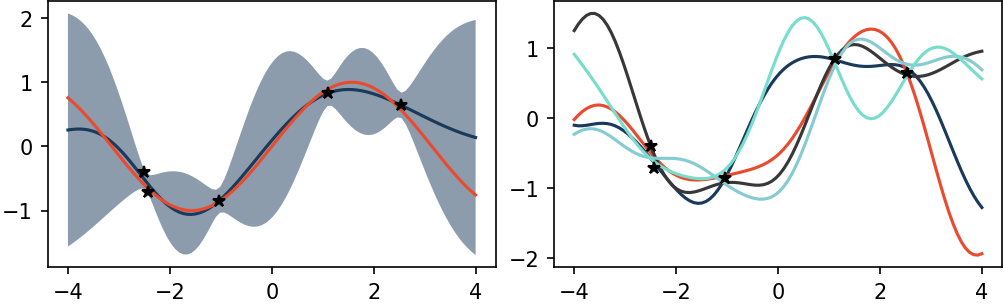

In [46]:
upper, lower = confidence_region(mu2, o2)
x_sin = np.linspace(domain[0], domain[1], 201)
params = figsizes.icml2022_full(ncols=2, nrows=1)
plt.rcParams.update(params)

plt.rcParams.update(cycler.cycler(color=palettes.tue_ai))
fig, ax = plt.subplots(1,2)
ax[0].plot(X2[:, 0],mu2.T)
ax[0].plot(x_sin,f_sin(x_sin))
ax[0].fill_between(X2[:, 0], lower, upper, alpha=0.5)
ax[0].plot(X1[:, 0],y1.T, 'k*')
ax[1].plot(X2[:, 0], y2.T) 
ax[1].plot(X1[:, 0],y1.T, 'k*')
#ax[0].legend(['Mean',"Sin(x)",'Confidence', 'Observed Data'])
plt.show()

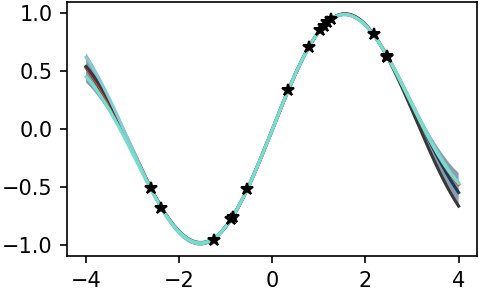

In [124]:
n1 = 15 # Number of points to condition on (training points)
n2 = 200  # Number of points in posterior (test points)
ny = 5  # Number of functions that will be sampled from the posterior
domain = (-4, 4)

X1 = np.random.uniform(domain[0] + 1, domain[1] - 1, size=(n1, 1))
y1 = f_sin(X1)
X2 = np.linspace(domain[0], domain[1], n2).reshape(-1, 1)
kernel = Kernel(covar_func=exponentiated_quadratic, lengthscale=2,signal_var=0.2)
mu2, Σ2 = GP(X1, y1, X2, kernel, observ_noise=0.005)
o2 = np.sqrt(np.diag(Σ2))

y2 = np.random.multivariate_normal(mean=mu2, cov=Σ2, size=ny)

upper, lower = confidence_region(mu2, o2)
x_sin = np.linspace(domain[0], domain[1], 201)
params = figsizes.icml2022_half(ncols=1, nrows=1)
plt.rcParams.update(params)

plt.rcParams.update(cycler.cycler(color=palettes.tue_ai))
fig, ax = plt.subplots(1,1)
ax.fill_between(X2[:, 0], lower, upper, alpha=0.5)
#ax[0].plot(x_sin,f_sin(x_sin),linestyle='--')
ax.plot(X2[:, 0], y2.T) 
#ax[0].legend(['Mean',"Sin(x)",'Confidence', 'Observed Data'])
ax.plot(X1[:, 0],y1.T, 'k*')
plt.show()